In [67]:
# Load libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys

%load_ext autoreload
%autoreload 2

# Import load_csv
sys.path.append("project")
from helpers import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
# Dataset shape without using pandas
x_train, x_test, y_train, train_ids, test_ids = load_csv_data('data/dataset')

print("Train set shape : ", x_train.shape)
print("Test set shape : ", x_test.shape)
print(test_ids)

Train set shape :  (328135, 320)
Test set shape :  (109379, 320)
[44 27 35 ...  9 15 45]


In [7]:
# Number of lines that contain NaN values in train set
count_rows_with_nan = np.sum(np.isnan(x_train).any(axis=1))
print("Number of rows containing at least one NaN in train set:", count_rows_with_nan)

# Number of columns that contain NaN values in train set
count_columns_with_nan = np.sum(np.isnan(x_train).any(axis=0))
print("Number of columns containing at least one NaN in train set:", count_columns_with_nan)

# Number of lines that contain NaN values in test set
count_rows_with_nan = np.sum(np.isnan(x_test).any(axis=1))
print("Number of rows containing at least one NaN in test set:", count_rows_with_nan)

# Number of columns that contain NaN values in test set
count_columns_with_nan = np.sum(np.isnan(x_test).any(axis=0))
print("Number of columns containing at least one NaN in test set:", count_columns_with_nan)

Number of rows containing at least one NaN in train set: 328135
Number of columns containing at least one NaN in train set: 239
Number of rows containing at least one NaN in test set: 109379
Number of columns containing at least one NaN in test set: 232


In [20]:
def show_NaN_cols(x, x_label):
    """
    Plot the percentage of columns of x that contains a specific percentage of NaN values

    Args:
        x (np.array): input data to analyze  
        x_label: string that describes the dataset x
    """
    
    percentiles = list(range(0, 101, 5))
    # Calcul du pourcentage des colonnes ayant un pourcentage de NaN entre x% et (x+5)%
    percentage_columns_with_percentile_nans = [
        (np.isnan(x).sum(axis=0)[
            (np.isnan(x).sum(axis=0) >= x.shape[0]*p/100) &
            (np.isnan(x).sum(axis=0) < x.shape[0]*(p+5)/100)
        ].shape[0] / x.shape[1]) * 100 for p in percentiles[:-1]  # Exclude the last percentile (100%)
    ]

    # Labels for the x-axis
    percentile_labels = [f'{p}-{p+5}%' for p in percentiles[:-1]]

    # Affichage du graphique
    plt.figure(figsize=(15, 6))
    plt.bar(percentile_labels, percentage_columns_with_percentile_nans)

    plt.title('Percentage of columns with NaN values in intervals of 5% in the {}'.format(x_label))
    plt.xlabel('Percentage Range of NaN')
    plt.ylabel('Percentage of columns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

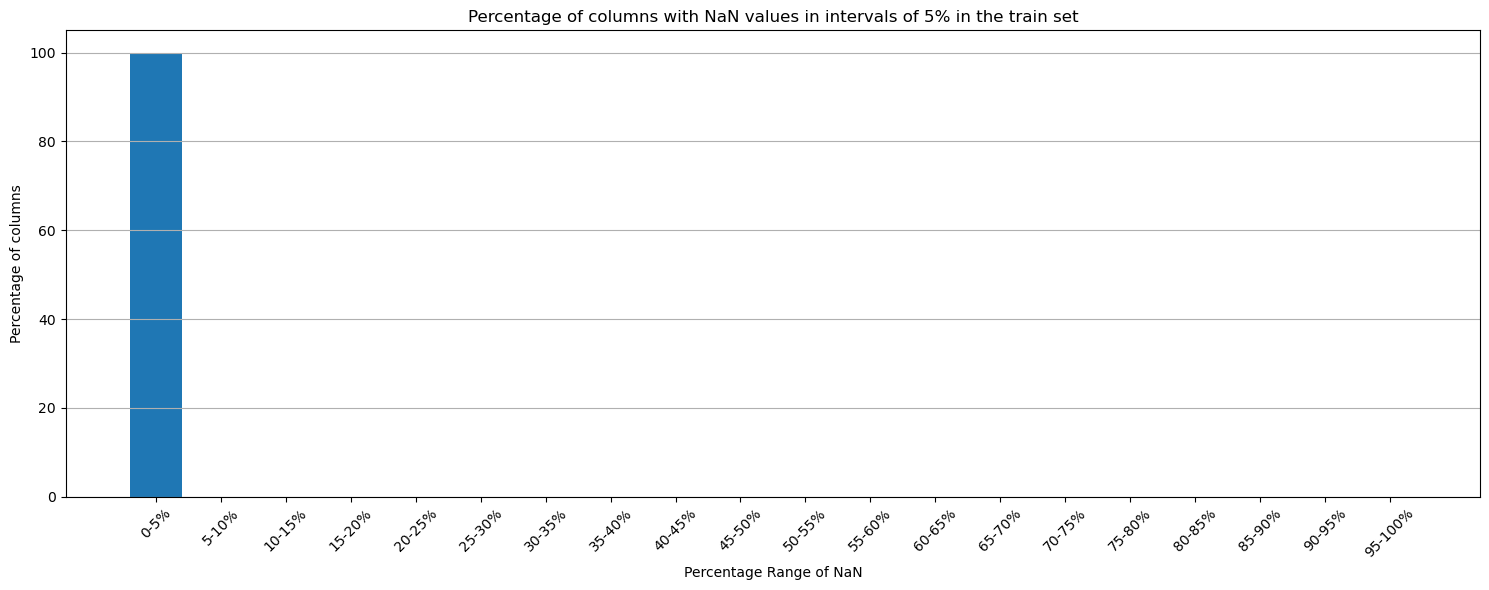

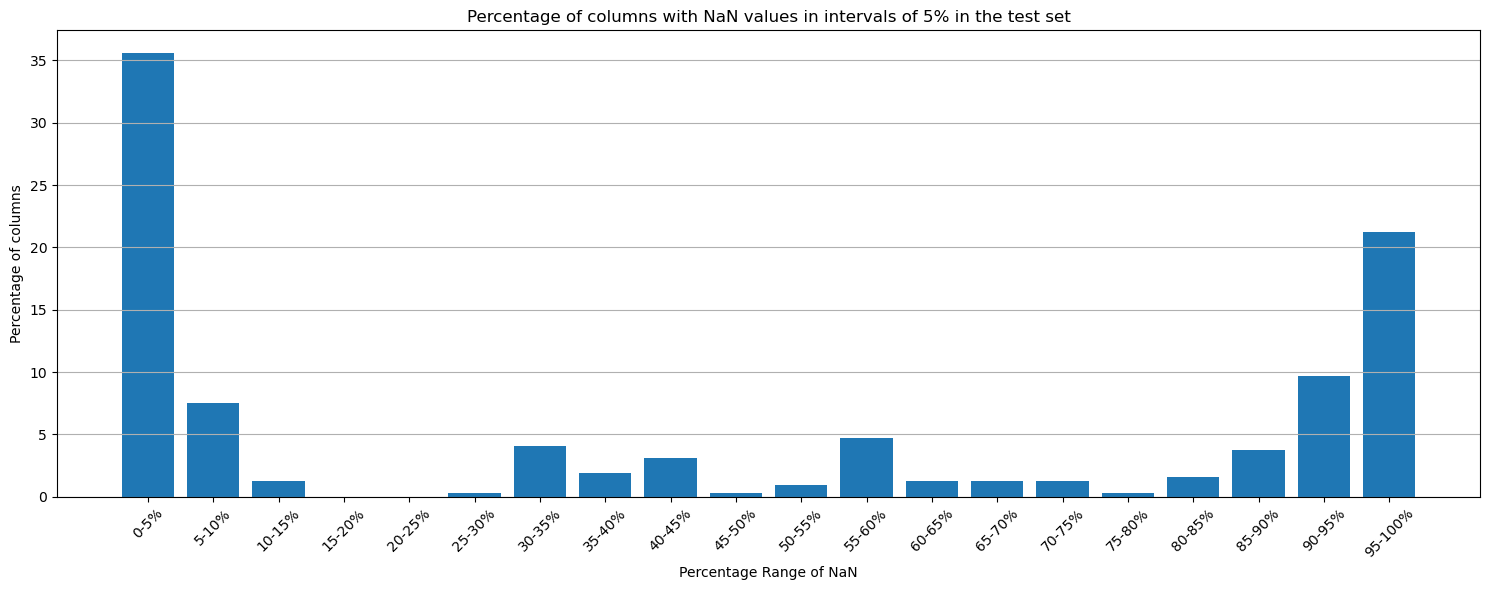

In [66]:
#Analyze the input
show_NaN_cols(x_train, "train set")
show_NaN_cols(x_test, "test set")

In [60]:
def filter_cols(x, threshold):
    """
    Add the mean of the columns with NaN and return indices of the columns to exclude in the regression including
    those were the standard deviation is equal to 0.
        
    Args:
        x (np.array): data
        threshold (int): % of NaN values that should contain a column of x
        
    Returns:
        f_x: data with NaN values replaces by zeroes
        rem_cols (np.array): list of indices of columns that contains more than threshold% of NaN values and that
            doesn't contain any 0 standard deviation
    """
    
    f_x = x
    error_matrix = np.isnan(x)
    
    #Identify indices of the columns with more than threshold percentage of NaN values
    nan_ = (np.sum(error_matrix, axis=0) / x.shape[0]) * 100
    rem_cols_NaN = np.where(nan_ > threshold)[0]
    
    #Replace NaN values with the mean of it's columns
    column_means = np.nanmean(f_x, axis=0)
    f_x[nan_mask] = np.take(column_means, np.where(error_matrix)[1])
    
    #Identify columns with 0 standard deviation
    std_x = np.std(f_x, axis=0)
    rem_cols_std = np.where(std_x == 0)[0]
    
    #Final array with indices of the columns to exclude in the classification
    rem_cols = np.unique(np.concatenate((rem_cols_NaN, rem_cols_std)))
    
    return f_x, rem_cols

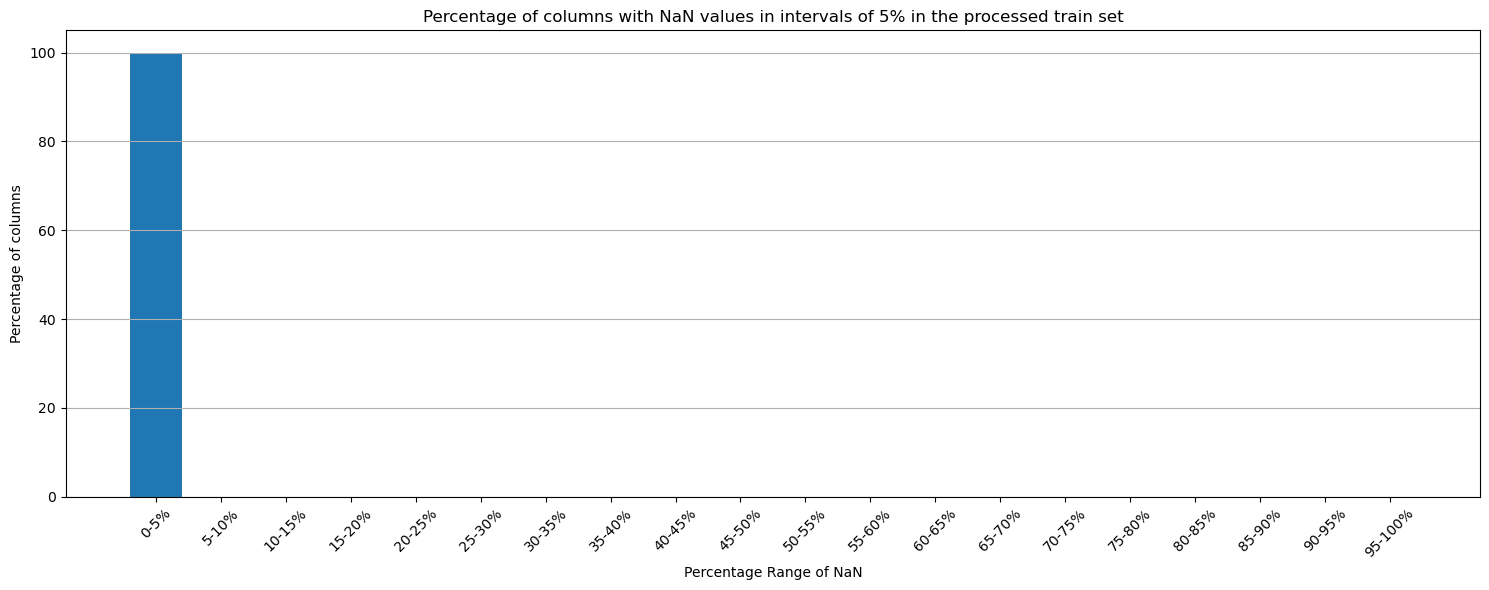

In [61]:
f_x, cols_excluded = filter_cols(x_train,50)
show_NaN_cols(f_x, "processed train set")

In [56]:
def standardize_std(x):
    """
    Standardize the columns of x, might do some other processing after
        
    Args:
        x (np.array): data
        
    Returns:
        s_x: standardized matrix 
    """
    
    s_x = standardize(x)
    
    return s_x

In [65]:
T_x, m_x, std_x = standardize_std(f_x)
print(std_x)

158800263.19653115
